<h1>Simple Moving Average Trading Strategy</h1>

<p>Utilising simple moving average 20 and 50 to long/short an asset and testing the strategy.</p>

In [61]:
# Importing necessary libraries
import yfinance as yf
import backtrader as bt
from datetime import datetime
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

In [42]:
class SmaCross(bt.Strategy):
    params = dict(
        pfast=20,  # period for the fast moving average
        pslow=50   # period for the slow moving average
    )

    def __init__(self):
        sma1 = bt.ind.SMA(period=self.p.pfast)  # fast moving average
        sma2 = bt.ind.SMA(period=self.p.pslow)  # slow moving average
        self.crossover = bt.ind.CrossOver(sma1, sma2)  # crossover signal

    def next(self):
        if not self.position:  # not in the market
            if self.crossover > 0:  # if fast crosses slow to the upside
                self.buy()  # enter long

        elif self.crossover < 0:  # in the market & fast crosses slow to the downside
            self.sell()  # close long position


<h2>Single Stock Backtesting</h2>

<p>The code below is for a single ticker, this allows us to see how the strategy performed for that single security.</p>

In [ ]:
cerebro = bt.Cerebro()
cerebro.addstrategy(SmaCross)

ticker = input("Enter the stock ticker symbol (e.g., AAPL): ").upper()
# Download historical data from Yahoo Finance
data = yf.download(ticker, start='2010-01-01', multi_level_index=False)

feed = bt.feeds.PandasData(dataname=data)
cerebro.adddata(feed)
cerebro.addsizer(bt.sizers.PercentSizer, percents=10)
cerebro.broker.setcommission(commission=0.005)  # 0.5% commission
cerebro.addanalyzer(bt.analyzers.AnnualReturn, _name='annual_return')

teststrat = cerebro.run()

# Print performance metrics
print("\n" + "="*50)
print(f"BACKTEST RESULTS FOR {ticker}")
print("="*50)
print(f"Starting Portfolio Value: ${10000:.2f}")
print(f"Final Portfolio Value: ${cerebro.broker.getvalue():.2f}")
print(f"Total Return: ${cerebro.broker.getvalue() - 10000:.2f}")
print(f"Total Return %: {((cerebro.broker.getvalue() - 10000) / 10000) * 100:.2f}%")
print(f"Commission Rate: 0.5%")
print(f"Position Size: 10% per trade")

# Get annual returns
annual_returns = teststrat[0].analyzers.annual_return.get_analysis()
print("\nAnnual Returns:")
for year, ret in annual_returns.items():
    print(f"  {year}: {ret*100:.2f}%")
print("="*50 + "\n")

%matplotlib inline
cerebro.plot(
        style='candlestick',
    barup='green', bardown='red',  # Color scheme
    plotdist=0.5,  # Spacing between subplots
    figsize=(14, 8),  # Larger figure size
    iplot=False
)

<h2>Portfolio Backtesting</h2>
<p>Below is a code which uses the same strategy but for a portfolio of choice.</p>

/var/folders/83/z6s9w3p55ql68pdbnzh4bszh0000gn/T/ipykernel_9067/140197531.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2010-01-01', multi_level_index=False)
[*********************100%***********************]  1 of 1 completed
/var/folders/83/z6s9w3p55ql68pdbnzh4bszh0000gn/T/ipykernel_9067/140197531.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2010-01-01', multi_level_index=False)
[*********************100%***********************]  1 of 1 completed
/var/folders/83/z6s9w3p55ql68pdbnzh4bszh0000gn/T/ipykernel_9067/140197531.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2010-01-01', multi_level_index=False)
[*********************100%***********************]  1 of 1 completed
/var/folders/83/z6s9w3p55ql68pdbnzh4bszh0000gn/T/ipykernel_9067/140197531.py:6: FutureWarning: YF


BACKTEST RESULTS FOR PORTFOLIO
Starting Portfolio Value: $100000.00
Final Portfolio Value: $117301.93
Total Return: $17301.93
Total Return %: 17.30%
Commission Rate: 0.5%
Position Size: 10% per trade

Annual Returns:
  2010: 0.00%
  2011: 0.00%
  2012: 1.14%
  2013: 1.02%
  2014: 0.58%
  2015: -1.37%
  2016: -0.02%
  2017: 2.38%
  2018: 0.08%
  2019: 5.02%
  2020: 5.37%
  2021: 0.57%
  2022: -2.87%
  2023: 1.73%
  2024: 2.10%
  2025: 0.60%



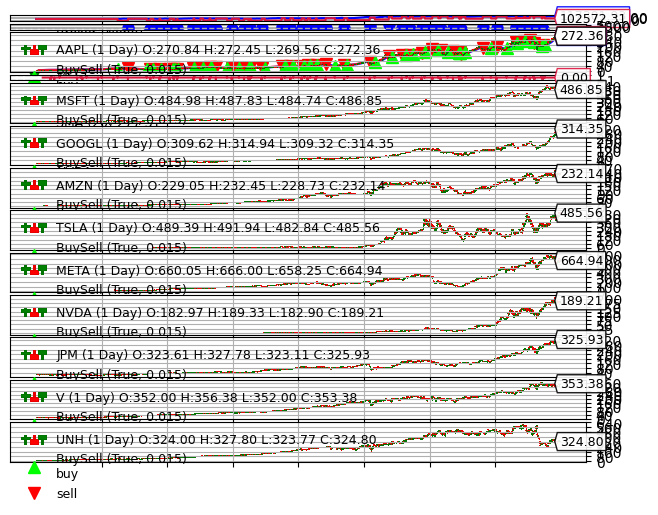

[[<Figure size 640x480 with 13 Axes>]]

In [87]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'JPM', 'V', 'UNH']

cerebro = bt.Cerebro()
cerebro.addstrategy(SmaCross)
for ticker in tickers:
    data = yf.download(ticker, start='2010-01-01', multi_level_index=False)
    feed = bt.feeds.PandasData(dataname=data)
    cerebro.adddata(feed, name=ticker)

cerebro.broker.setcash(100000)  # Set initial cash
cerebro.addsizer(bt.sizers.PercentSizer, percents=10) # 10% position size
cerebro.broker.setcommission(commission=0.005)  # 0.5% commission
cerebro.addanalyzer(bt.analyzers.AnnualReturn, _name='annual_return')

# Strategy trades across all of them simultaneously
cerebro.run()

teststrat = cerebro.run()

# Print performance metrics
print("\n" + "="*50)
print(f"BACKTEST RESULTS FOR PORTFOLIO")
print("="*50)
print(f"Starting Portfolio Value: ${100000:.2f}")
print(f"Final Portfolio Value: ${cerebro.broker.getvalue():.2f}")
print(f"Total Return: ${cerebro.broker.getvalue() - 100000:.2f}")
print(f"Total Return %: {((cerebro.broker.getvalue() - 100000) / 100000) * 100:.2f}%")
print(f"Commission Rate: 0.5%")
print(f"Position Size: 10% per trade")

# Get annual returns
annual_returns = teststrat[0].analyzers.annual_return.get_analysis()
print("\nAnnual Returns:")
for year, ret in annual_returns.items():
    print(f"  {year}: {ret*100:.2f}%")
print("="*50 + "\n")

%matplotlib inline
cerebro.plot(
    style='candlestick',
    barup='green', bardown='red',  # Color scheme
    plotdist=0.5,  # Spacing between subplots
    figsize=(50, 44),  # Larger figure size
    iplot=False
)